In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,confusion_matrix,roc_curve,roc_auc_score)

In [2]:
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')
print("all imprts sucessfully")

all imprts sucessfully


In [3]:
df=pd.read_csv('data/creditcard.csv')

In [4]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [5]:
df.shape

(284807, 31)

In [6]:
df.size

8829017

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
#featue engineering
# create new features based on eda 
#1hour time in seconds
df['Hour']=(df['Time']/3600)%24
df['Hour']=df['Hour'].astype(int)

#Amount bins (we saw fraud clusters in small amount)

df['Amount_bins']=pd.cut(df['Amount'],bins=[0,10,50,200,500,float('inf')],labels=[0,1,2,3,4], include_lowest=True)
df['Amount_bins']=df['Amount_bins'].astype(float)
                         

In [9]:
df['Hour']


0          0
1          0
2          0
3          0
4          0
          ..
284802    23
284803    23
284804    23
284805    23
284806    23
Name: Hour, Length: 284807, dtype: int64

In [10]:
df['Hour'].isnull().sum()

np.int64(0)

In [11]:
df['Amount_bins'].isnull().sum()

np.int64(0)

In [12]:
# log transform amount(reduce outlier effect)
df['Amount_log']=np.log1p(df['Amount'])

In [13]:
df['Amount_log'].isnull().sum()

np.int64(0)

In [14]:
print("New features added:")
print(df[['Hour', 'Amount_bins', 'Amount_log', 
          'Amount', 'Class']].head(10))

New features added:
   Hour  Amount_bins  Amount_log  Amount  Class
0     0          2.0    5.014760  149.62      0
1     0          0.0    1.305626    2.69      0
2     0          3.0    5.939276  378.66      0
3     0          2.0    4.824306  123.50      0
4     0          2.0    4.262539   69.99      0
5     0          0.0    1.541159    3.67      0
6     0          0.0    1.790091    4.99      0
7     0          1.0    3.732896   40.80      0
8     0          2.0    4.545420   93.20      0
9     0          0.0    1.543298    3.68      0


first we converted time seconds into hourly basis which i can see 0 then we created a bin
evry ruppee we created a box where value are considered inside the box onnce it found value greter than mentioned number it goes in that box then creted log so that fraud higher amount is normalized closed to 1 logp would have been used but 0 will become infinity or - log1p makes data balance  0  will be 0.0 

why transactions are zero
Zero amount transactions actually happen:
1. Card verification check
   → Bank sends €0 transaction to verify card is active
   → Common when you save card on Amazon/Netflix

2. Refund processing
   → Merchant initiates €0 to check refund channel

3. Authorization hold
   → Hotel/car rental places €0 auth before actual charge

4. Free trials
   → Netflix free month — transaction recorded as €0

In our dataset:
fraud_df[fraud_df['Amount']==0].shape
→ Some fraud transactions are €0 too
→ Fraudsters test stolen cards with €0 first
   If it works → then charge larger amount
   This is called "card testing fraud"

In [15]:
# seprate fetatures and target
#drop origiunal time  and amount
x=df.drop(['Class','Time','Amount'],axis=1)
y=df['Class']
print("Features shape:", x.shape)
print("Target shape:", y.shape)
print("Feature columns:", x.columns.tolist())

Features shape: (284807, 31)
Target shape: (284807,)
Feature columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Hour', 'Amount_bins', 'Amount_log']


In [16]:
# dont do preprocessing before splitting
# Split BEFORE scaling — Data leakage rule!

In [17]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y) 
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)
print(f"\fraud in train:{Y_train.sum()}({Y_train.mean()*100:.2f}%)")
print(f"\fraud in test:{Y_test.sum()}({Y_test.mean()*100:.2f}%)")      

(199364, 31)
(85443, 31)
(199364,)
(85443,)
raud in train:344(0.17%)
raud in test:148(0.17%)


In [19]:
# Scale only Amount_log and Hour
# V1-V28 already PCA scaled
# Amount_bin is categorical (0-4)


scaler=StandardScaler()
scale_cols=['Amount_log','Hour']
X_train[scale_cols]=scaler.fit_transform(X_train[scale_cols])

X_test[scale_cols]=scaler.transform(X_test[scale_cols])      
print("scalling down")
print(X_train[scale_cols].describe().round(3))

scalling down
       Amount_log        Hour
count  199364.000  199364.000
mean       -0.000       0.000
std         1.000       1.000
min        -1.905      -2.409
25%        -0.759      -0.694
50%        -0.011       0.163
75%         0.730       0.849
max         4.227       1.535


In [21]:
X_train[scale_cols]

,Amount_log,Hour
249927,-0.639152,0.677865
214082,1.125111,-0.008151
106005,2.426709,0.849369
58619,-0.876241,-0.179655
191638,-0.876241,-0.522663
...,...,...
3441,-1.485992,-2.409207
233802,-0.730381,0.506361
85418,0.291832,0.334857
29062,0.412847,-0.865671


In [22]:
X_train

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Hour,Amount_bins,Amount_log
249927,-0.012102,0.707332,0.163334,-0.756498,0.590999,-0.653429,0.844608,-0.001672,-0.184399,-0.222719,...,-0.572415,0.042660,-0.360882,-0.494703,0.142657,0.235922,0.083758,0.677865,0.0,-0.639152
214082,1.776151,-0.184642,-2.204096,1.191668,0.614461,-1.016525,0.919254,-0.387465,-0.318277,0.517022,...,0.530070,-0.232262,-0.342096,0.492355,-0.427682,-0.075228,-0.056755,-0.008151,2.0,1.125111
106005,-1.083391,-4.440527,-1.399530,0.469764,-2.076458,-0.766137,1.601441,-0.709176,-1.288745,0.086419,...,-1.432833,-1.097063,0.505926,-0.140185,0.870190,-0.316982,0.227833,0.849369,4.0,2.426709
58619,-0.518847,1.025087,-0.614624,-0.780959,2.474666,3.335055,0.046111,0.794249,-0.322448,0.128383,...,-0.708348,0.145672,0.944217,-0.788017,0.039995,0.010804,0.254309,-0.179655,0.0,-0.876241
191638,-0.640421,0.212171,0.283341,-1.786916,2.616127,4.024863,-0.198897,0.937087,0.474428,-0.283699,...,0.759218,-0.321412,0.767971,-0.084221,0.612936,0.074029,-0.033344,-0.522663,0.0,-0.876241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3441,-0.415022,0.713439,1.221551,-2.108216,0.187067,-1.281616,1.118548,-0.345326,0.463473,-0.999876,...,0.756938,-0.290888,0.558730,0.037363,-0.871689,0.239482,-0.020422,-2.409207,0.0,-1.485992
233802,1.993864,-0.516866,-0.620118,0.129845,-0.285128,0.395044,-0.822358,0.231591,0.995898,0.212619,...,0.884510,0.099141,0.275689,-0.195404,0.623598,-0.032455,-0.058552,0.506361,0.0,-0.730381
85418,-1.497933,0.657921,1.581568,-0.024286,0.584698,1.303031,0.609212,0.135561,0.452745,0.108640,...,0.299172,0.110048,-0.615980,-0.425883,0.263968,-0.448445,0.045178,0.334857,1.0,0.291832
29062,1.069777,0.072105,0.496540,1.505318,-0.380277,-0.370243,0.100551,-0.026687,0.319684,-0.131553,...,-0.044629,-0.050485,0.400171,0.593314,-0.335160,0.031014,0.024886,-0.865671,1.0,0.412847


In [23]:
# CELL IMBALANCE 
from imblearn.over_sampling import SMOTE
print("Before Smote:")
print(f"Fraud: {Y_train.sum()}")
print(f"Normal: {(Y_train==0).sum()}")

Before Smote:
Fraud: 344
Normal: 199020


In [24]:
# SMPOTE CREATES SYNTHETIC SAMPLES 
smote=SMOTE(random_state=42)
x_train_balanced,y_train_balanced=smote.fit_resample(X_train,Y_train)

print("After sample:")
print(f"Fraud: {y_train_balanced.sum()}")
print(f"Normal: {(y_train_balanced==0).sum()}")

After sample:
Fraud: 199020
Normal: 199020


#
ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider
sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following
    page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

so i checked all missing values noticed amount_bin has 1825 missing values reason is 0.0 which exist but in bin it doesnt get collected 
pd.cut(df['Amount'], bins=[0, 10, 50, 200, 500, inf])

Problem: bins start at 0 but NOT INCLUDING 0
pd.cut uses (left, right] by default
meaning: 0 is NOT included in any bin

So any transaction with Amount = 0.00
falls outside all bins → becomes NaN

How many zero amounts exist?
df[df['Amount'] == 0].shape → 1825 rows
That's exactly your 1825 NaN values!

: "if we don't use stratify maximum 0s 
will go to training, nothing left for test"

Confirmed. Without stratify:
Train might get: 99.9% normal, 0.05% fraud
Test might get:  99.7% normal, 0.3% fraud

With stratify=y:
Train: 99.83% normal, 0.17% fraud
Test:  99.83% normal, 0.17% fraud
→ Same fraud ratio in both splits
→ Evaluation is honest and representative

: "creates synthetic samples based on 
random sample, goes closer to every data, 
makes data balanced"



SMOTE full process:
1. Take a fraud sample (point A)
2. Find its K nearest fraud neighbors
3. Draw a line between A and one neighbor (point B)
4. Create new synthetic point SOMEWHERE on that line
   (random position between A and B)
5. Repeat until classes balanced

vs Simple duplication:
→ Just copies existing fraud rows
→ Model memorizes those exact rows
→ Overfits to the 492 original fraud patterns

SMOTE advantage:
→ Creates NEW points between existing fraud samples
→ Model learns the REGION of fraud
→ Not just the exact 492 points
→ Better generalization

SMOTE only applied on TRAINING data ✅
Test data still has original imbalance:
Fraud:  148  (20% of 492)
Normal: ~56,000

Why keep test imbalanced?
Test simulates real world
Real world IS imbalanced
If we balance test → evaluation is fake

#MLFLOW

Without MLflow:
You train 10 models
Change parameters each time
Forget which parameters gave best result
Can't compare them properly
"Was it max_depth=5 or 6 that gave 0.94 AUC?"

With MLflow:
Every experiment automatically recorded:
→ What parameters you used
→ What metrics you got
→ Which model file was saved
→ When you ran it
→ Compare all runs in one dashboard

You run Logistic Regression  → MLflow saves it
You run Random Forest        → MLflow saves it  
You run XGBoost              → MLflow saves it

Go to localhost:5000
See all three side by side:

Run Name          | AUC   | F1    | Precision | Recall
─────────────────────────────────────────────────────
LogisticRegression| 0.91  | 0.78  | 0.82      | 0.74
RandomForest      | 0.95  | 0.86  | 0.89      | 0.83
XGBoost           | 0.97  | 0.91  | 0.93      | 0.89

Click best run → see exact parameters used
Click model    → download and deploy it

1. Parameters  → what settings you used
                 max_depth=10, n_estimators=100

2. Metrics     → how well it performed
                 AUC=0.97, F1=0.91

3. Artifacts   → the actual model file
                 model.pkl saved automatically

4. Tags        → extra info
                 "author: Roshan", "dataset: creditcard"

In [29]:
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             f1_score,
                             precision_score,
                             recall_score)

In [30]:
#set experiment name 
mlflow.set_experiment("fraud_detection")

<Experiment: artifact_location='file:C:/Users/Hp/fraud-detection/mlruns/1', creation_time=1780723958680, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1780723958680, lifecycle_stage='active', name='fraud_detection', tags={}, trace_location=None, workspace='default'>

In [33]:
with mlflow.start_run(run_name="Logistic_regression_baseline"):
    model=LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')# extra safety besides smote

    #log parameters
    mlflow.log_param("model_type","LogisticRegression")
    mlflow.log_param("max_iter",1000)
    mlflow.log_param("class_weight","balanced")
    mlflow.log_param("train_samples","len(X_train_balanced")
    mlflow.log_param("smote_applied",True)


    model.fit(x_train_balanced,y_train_balanced)
    print("modeltrained")

    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:,1]

    auc=roc_auc_score(Y_test,y_prob)
    f1=f1_score(Y_test,y_pred)
    prec=precision_score(Y_test, y_pred)
    rec=recall_score(Y_test, y_pred)


    mlflow.log_metric("auc",auc)
    mlflow.log_metric("fi",f1)
    mlflow.log_metric("prec",prec)
    mlflow.log_metric("rec",rec)

    mlflow.sklearn.log_model(model,"model")

    print("\n" + "="*50)
    print("LOGISTIC REGRESSION BASELINE RESULTS")
    print("="*50)
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")

    print("\nDetailed Report:")
    print(classification_report(Y_test,y_pred,target_names=['Normal','Fraud']))

    run_id=mlflow.active_run().info.run_id
    print(f"\nMLFOW RUNID:,{run_id}")
    
    
    
    


modeltrained


2026/06/06 14:57:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 14:57:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



LOGISTIC REGRESSION BASELINE RESULTS
AUC-ROC:   0.9701
F1 Score:  0.1108
Precision: 0.0591
Recall:    0.8784

Detailed Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     85295
       Fraud       0.06      0.88      0.11       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443


MLFOW RUNID:,a62d0b252c024f378e3064772d634e4a


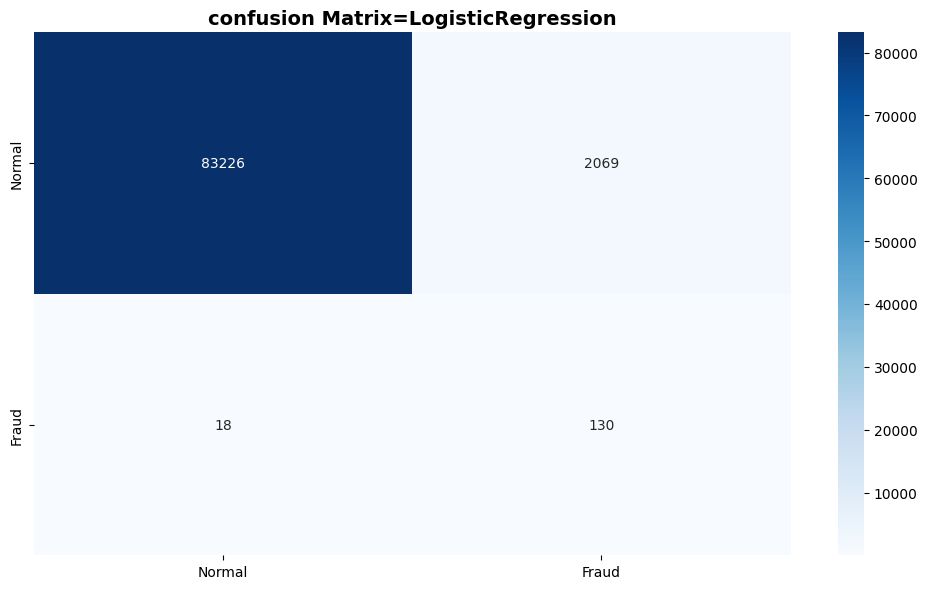


True Negatives  (Normal correctly identified): 83226
False Positives (Normal flagged as Fraud):     2069
False Negatives (Fraud missed):                18
True Positives  (Fraud correctly caught):      130

Fraud catch rate: 87.8%
False alarm rate: 2.4%


In [37]:
#visualize  what model got right and wrong

cm=confusion_matrix(Y_test,y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('confusion Matrix=LogisticRegression',fontweight='bold',fontsize=14)
plt.ylabel=('Actual')
plt.xlabel=('predicted')
plt.tight_layout()
plt.savefig('notebooks/confusion_matrix_lr.png')
plt.show()

tn, fp, fn, tp =cm.ravel()
print(f"\nTrue Negatives  (Normal correctly identified): {tn}")
print(f"False Positives (Normal flagged as Fraud):     {fp}")
print(f"False Negatives (Fraud missed):                {fn}")
print(f"True Positives  (Fraud correctly caught):      {tp}")
print(f"\nFraud catch rate: {tp/(tp+fn)*100:.1f}%")
print(f"False alarm rate: {fp/(fp+tn)*100:.1f}%")
          

WHAT WE NOW 
X_train after SMOTE: 398,040 samples (balanced)
Fraud:  199,020
Normal: 199,020

X_test: 85,443 samples (original imbalance)
Fraud:  148
Normal: 85,295

WHAT MODEL PREDICTED ON TEST
Confusion Matrix:

                 Predicted Normal  Predicted Fraud
Actual Normal        83,226            2,069
Actual Fraud             18              130

83,226 → True Negatives
Normal transactions model correctly said NORMAL 

2,069  → False Positives  
Normal transactions model WRONGLY said FRAUD 
These are innocent customers getting blocked

18     → False Negatives
Fraud transactions model WRONGLY said NORMAL 
These are missed frauds — money lost

130    → True Positives
Fraud transactions model correctly said FRAUD 


Recall = TP / (TP + FN)
       = 130 / (130 + 18)
       = 130 / 148
       = 0.878 → 87.8%

Meaning:
Out of 148 actual fraud cases
Model caught 130 of them 
Missed only 18 

Recall only looks at FRAUD rows
It doesn't care about normal rows at all
That's why recall is high


WHY PRECISION BECOMES LOW 
Precision = TP / (TP + FP)
          = 130 / (130 + 2069)
          = 130 / 2199
          = 0.059 → 5.9%

Meaning:
Every time model said "THIS IS FRAUD"
It made that claim 2,199 times total
But only 130 of those were actually fraud
2,069 were innocent normal transactions

So out of every 100 fraud alerts:
Only 6 are real fraud
94 are false alarms

REASON
SMOTE made training data:
Fraud:  199,020 (50%)
Normal: 199,020 (50%)

Model learned in training:
"Fraud and Normal are equally common"
"When I see something suspicious → say fraud"
"Better safe than sorry"

But real test data:
Fraud:  148    (0.17%)
Normal: 85,295 (99.83%)

Model is still thinking fraud is 50% likely
So it flags 2,069 + 130 = 2,199 as fraud
But only 148 are actually fraud
Result → terrible precision



At threshold 0.5:
Model says fraud for everything above 0.5
→ Catches most real fraud (high recall)
→ But also catches many normals (low precision)
→ 2,069 false alarms

If we raise threshold to 0.8:
Model only flags when VERY confident
→ Fewer false alarms (higher precision)
→ But misses some real fraud (lower recall)

18 False Negatives = fraud the model missed

These 18 fraud transactions looked like normal ones
Their V1-V28 values were close to normal range
Model scored them below 0.5 threshold
Said "normal" but they were actually fraud

Why?
Fraudsters sometimes make transactions that
look completely normal in amount and behavior
Only difference is in subtle V feature patterns
Logistic Regression (linear model) couldn't
capture those subtle non-linear patterns

Random Forest and XGBoost will catch more of these
Because they learn non-linear boundaries

AUC = 0.97 means the model CAN distinguish
fraud from normal very well internally

The precision problem is fixable:
1. Better model (XGBoost tomorrow)
2. Threshold tuning
3. Remove double balancing (SMOTE + class_weight)

This baseline result is actually NORMAL
for a first logistic regression on imbalanced data
You will see dramatic improvement with XGBoost

NEW DATA IS ALWAYS RANDOM 
Training taught the model patterns:
"When V17 < -5 AND V14 < -6 AND Amount < 100
 → probability of fraud is HIGH"

New transaction comes in (never seen before):
V17 = -8.3, V14 = -7.1, Amount = 45

Model doesn't need to have seen THIS transaction
It applies the LEARNED PATTERN to new data


In [43]:
import joblib
import os

# Create processed data folder
os.makedirs('models', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# Save processed data
import numpy as np
np.save('data/processed/X_train_bal.npy', 
        x_train_balanced)
np.save('data/processed/y_train_bal.npy', 
        y_train_balanced)
np.save('data/processed/X_test.npy', 
        X_test.values)
np.save('data/processed/y_test.npy', 
        Y_test.values)

# Save scaler
joblib.dump(scaler, 'models/scaler.pkl')

# Save feature names
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'models/feature_names.pkl')

print("Saved:")
print("✅ X_train_bal")
print("✅ y_train_bal")
print("✅ X_test")
print("✅ y_test")
print("✅ scaler.pkl")
print("✅ feature_names.pkl")

Saved:
✅ X_train_bal
✅ y_train_bal
✅ X_test
✅ y_test
✅ scaler.pkl
✅ feature_names.pkl


In [44]:
# Save original train data too
np.save('data/processed/X_train_orig.npy', 
        X_train.values)
np.save('data/processed/y_train_orig.npy', 
        Y_train.values)

print("✅ X_train_orig saved")
print("✅ y_train_orig saved")

✅ X_train_orig saved
✅ y_train_orig saved
